# ==========================================
# OASIS INFOBYTE - DATA SCIENCE INTERNSHIP
# TASK 3: Email Spam Detection
# Author: Muhammad Farhan
# Track: Data Science
# Repo Name: OIBSIP
# ==========================================

### ==============================================================================
### SECTION 1: DATA LOADING, STRUCTURE INSPECTION & QUALITY CHECKS
### ==============================================================================
### Objective: Load the raw Advertising dataset, convert it to a structured DataFrame,
### check for missing values, and analyze basic statistical metrics.
### Import & install required libraries

In [1]:
pip install nltk wordcloud

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [4]:
df = pd.read_csv('spam.csv',encoding='latin_1')

In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
df = df[['v1','v2']]

In [8]:
df.columns = ['labels','message']

In [9]:
df['labels'].value_counts()

labels
ham     4825
spam     747
Name: count, dtype: int64

In [10]:
df.duplicated().sum()

403

In [11]:
df = df.drop_duplicates()

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   labels   5169 non-null   object
 1   message  5169 non-null   object
dtypes: object(2)
memory usage: 121.1+ KB


### ==============================================================================
### SECTION 2: VISUAL EXPLORATORY DATA ANALYSIS (EDA)
### ==============================================================================

In [13]:
df['labels'].value_counts(normalize = True)*100

labels
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

In [14]:
import os
os.makedirs('DataScience-Task3-Emailspamdetection/images',exist_ok=True)

/tmp/ipykernel_512/2086025147.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='labels', palette=['#4CAF50', '#F44336'])


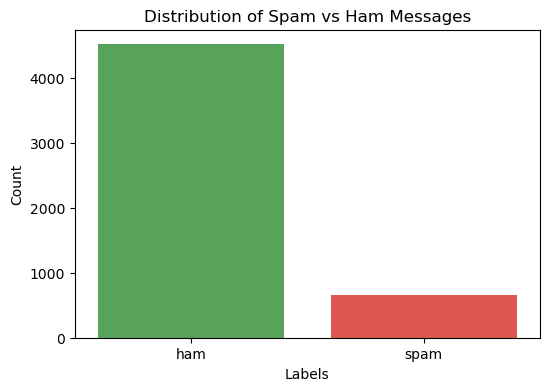

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='labels', palette=['#4CAF50', '#F44336'])
plt.title('Distribution of Spam vs Ham Messages')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.savefig('images/spam_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### ==============================================================================
### SECTION 3: DATA PREPROCESSING & TRAIN-TEST SPLIT
### ==============================================================================

In [16]:
import nltk 
from nltk.corpus import stopwords as nltk_stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/4348cc34-6565-4da0-8cfe-
[nltk_data]     d853b52489ea/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:
stopwords = set(nltk_stopwords.words('english'))

# Function Parameter ka naam 'input_text' rakha hai taaki 'text' ya 'string' se conflict na ho
def clean_text(input_text):
    if not isinstance(input_text, str):
        input_text = str(input_text)
        
    cleaned = input_text.lower()
    cleaned = re.sub(r'\d+', '', cleaned)
    cleaned = cleaned.translate(str.maketrans('', '', string.punctuation))
    
    words = cleaned.split()
    words = [word for word in words if word not in stopwords]
    return ' '.join(words)

# Apply command
df['cleaned_message'] = df['message'].apply(clean_text)
df[['message', 'cleaned_message']].head()

,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [20]:
df['label_num'] = df['labels'].map({'ham':0 , 'spam':1})

X = df['cleaned_message']
y = df['label_num']

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Training shape: (4135, 7398)
Test shape: (1034, 7398)


### ==============================================================================
### Section 4: MODEL TRAINING & EVALUATION (Naive Bayes & Logistic Regression)
### ==============================================================================

In [21]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb  = nb_model.predict(X_test_tfidf)

In [22]:
lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

In [23]:
print("=== Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1-Score:", f1_score(y_test, y_pred_nb))

=== Naive Bayes ===
Accuracy: 0.9642166344294004
Precision: 1.0
Recall: 0.7448275862068966
F1-Score: 0.8537549407114624


In [24]:
print("\n=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-Score:", f1_score(y_test, y_pred_lr))


=== Logistic Regression ===
Accuracy: 0.9545454545454546
Precision: 0.9375
Recall: 0.7241379310344828
F1-Score: 0.8171206225680934


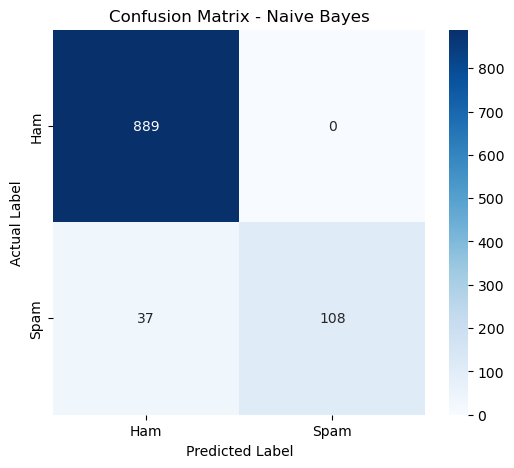

In [27]:
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Naive Bayes')
# plt.savefig('images/spam_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

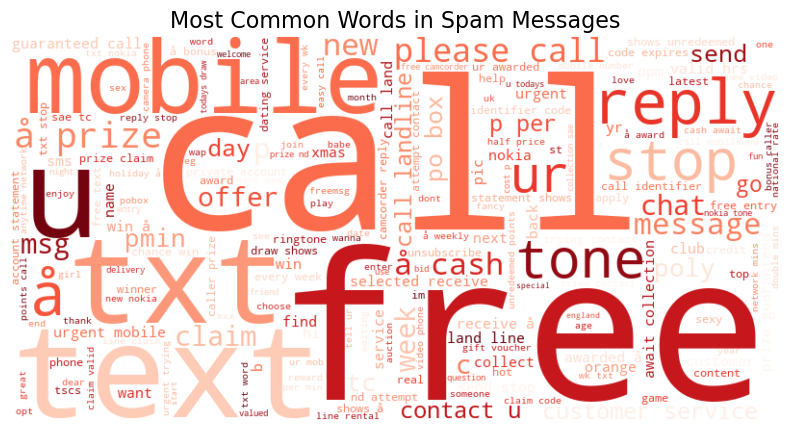

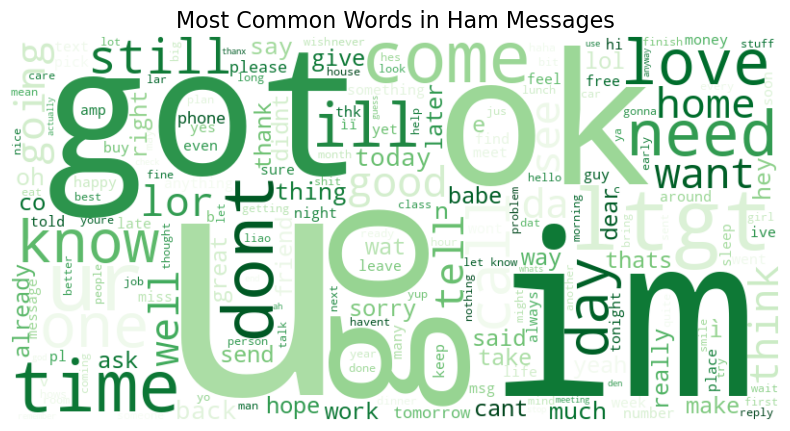

In [28]:
from wordcloud import WordCloud

# Spam messages ka text alag nikalein
spam_text = ' '.join(df[df['labels'] == 'spam']['cleaned_message'])
ham_text = ' '.join(df[df['labels'] == 'ham']['cleaned_message'])

# Spam WordCloud
plt.figure(figsize=(10, 5))
wordcloud_spam = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(spam_text)
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Spam Messages', fontsize=16)
plt.savefig('images/spam_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

# Ham WordCloud
plt.figure(figsize=(10, 5))
wordcloud_ham = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(ham_text)
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Ham Messages', fontsize=16)
plt.savefig('images/ham_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
import joblib

joblib.dump(nb_model, 'spam_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']